# Hotel Demand Forecasting

**Objective:** Forecast weekly hotel bookings for the next 52 weeks to optimize capacity planning

**Business Question:** How many bookings should we expect each week for our City Hotel and Resort Hotel?

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Set nice visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## Step 1: Load and Explore the Data

In [2]:
# Load hotel booking data
df = pd.read_csv('cleaned_hotel_bookings.csv')
df['week_start'] = pd.to_datetime(df['week_start'])

# Aggregate to weekly level

weekly = (
    df.groupby(["week_start", "hotel"])
      .agg(
          net_booking=("net_booking", "sum"),
          room_nights=("total_stay_nights", "sum"),
          avg_adr=("adr", "mean")
      )
      .reset_index()
)

weekly.head()

print(f"Data Summary:")
print(f"   • Total weeks of data: {len(weekly['week_start'].unique())}")
print(f"   • Date range: {weekly['week_start'].min().date()} to {weekly['week_start'].max().date()}")
print(f"   • Hotels: {', '.join(weekly['hotel'].unique())}\n")

# Show sample data
weekly.head(10)

Data Summary:
   • Total weeks of data: 114
   • Date range: 2015-06-29 to 2017-08-28
   • Hotels: City Hotel, Resort Hotel



,week_start,hotel,net_booking,room_nights,avg_adr
0,2015-06-29,City Hotel,85,525,77.674158
1,2015-06-29,Resort Hotel,171,1216,102.208091
2,2015-07-06,City Hotel,61,710,71.252366
3,2015-07-06,Resort Hotel,218,1448,115.213872
4,2015-07-13,City Hotel,123,952,73.904353
5,2015-07-13,Resort Hotel,252,1599,129.501637
6,2015-07-20,City Hotel,134,1110,66.389602
7,2015-07-20,Resort Hotel,232,1680,144.029935
8,2015-07-27,City Hotel,75,587,65.611957
9,2015-07-27,Resort Hotel,249,1864,149.074884


**Insight:** We have approximately 2 years of weekly booking data for both hotels - enough for reliable forecasting.

## Step 2: Visualize Historical Booking Trends

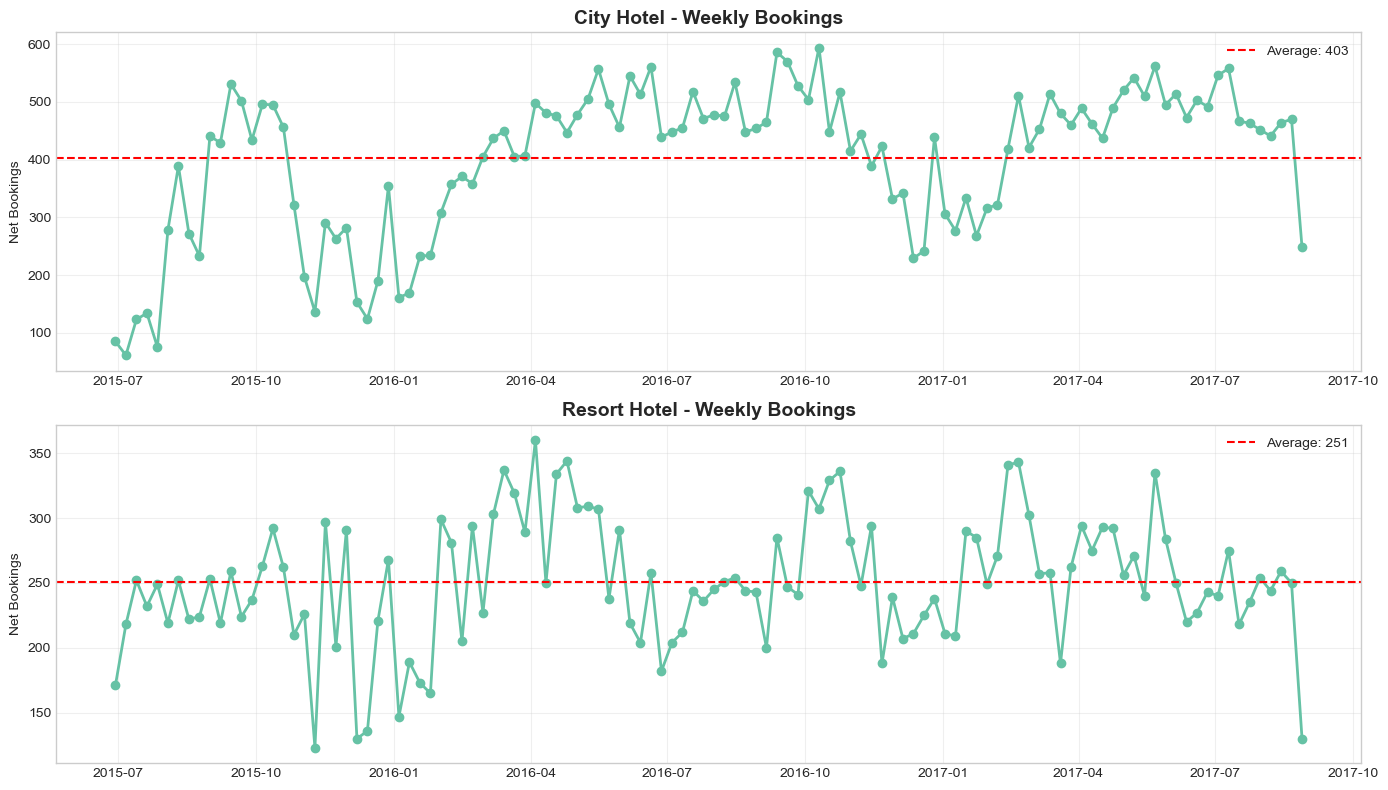


 Key Observations:

City Hotel:
   • Average: 403 bookings/week
   • Range: 61 to 594
   • Variability: 31.8%

Resort Hotel:
   • Average: 251 bookings/week
   • Range: 123 to 360
   • Variability: 19.5%


In [3]:
# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, hotel in enumerate(['City Hotel', 'Resort Hotel']):
    data = weekly[weekly['hotel'] == hotel]
    axes[idx].plot(data['week_start'], data['net_booking'], marker='o', linewidth=2)
    axes[idx].axhline(data['net_booking'].mean(), color='red', linestyle='--', label=f"Average: {data['net_booking'].mean():.0f}")
    axes[idx].set_title(f'{hotel} - Weekly Bookings', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Net Bookings')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('booking_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Key Observations:")
for hotel in ['City Hotel', 'Resort Hotel']:
    data = weekly[weekly['hotel'] == hotel]['net_booking']
    print(f"\n{hotel}:")
    print(f"   • Average: {data.mean():.0f} bookings/week")
    print(f"   • Range: {data.min():.0f} to {data.max():.0f}")
    print(f"   • Variability: {(data.std()/data.mean()*100):.1f}%")

**Business Insight:** 
- City Hotel has higher average bookings but more variability
- Resort Hotel shows more stable patterns - easier to forecast
- Both show seasonal patterns with peaks during summer months

## Step 3: Test Multiple Forecasting Methods

In [4]:
# Split data: last 12 weeks for testing accuracy
results = []

for hotel in ['City Hotel', 'Resort Hotel']:

    data = weekly[weekly['hotel'] == hotel].sort_values('week_start')
    train = data.iloc[:-12]['net_booking'].values
    test = data.iloc[-12:]['net_booking'].values

    # -----------------------------
    # Method 1: Simple Moving Average
    # -----------------------------
    rolling_predictions = []
    rolling_data = list(train.copy())

    for week in range(12):
        avg = np.mean(rolling_data[-4:])
        rolling_predictions.append(avg)
        rolling_data.append(avg)

    mape_sim_avg = np.mean(np.abs((test - rolling_predictions) / test)) * 100

    # -----------------------------
    # Method 2: Weighted Moving Average
    # -----------------------------
    weights = np.array([1, 2, 3, 4])
    weighted_rolling_prediction = []
    weighted_rolling_data = train.copy()

    for week in range(12):
        weighted_avg = np.average(weighted_rolling_data[-4:], weights=weights)
        weighted_rolling_prediction.append(weighted_avg)
        weighted_rolling_data = np.append(weighted_rolling_data, weighted_avg)

    mape_weigh_avg = np.mean(np.abs((test - weighted_rolling_prediction) / test)) * 100

    # -----------------------------
    # Method 3: Simple Exponential Smoothing
    # -----------------------------
    def simple_exponential_smoothing_rolling(train_data, test_data, alpha=0.3):

        level = train_data[0]

        for t in range(1, len(train_data)):
            level = alpha * train_data[t] + (1 - alpha) * level

        forecasts = []
        for week in range(len(test_data)):
            forecast = level
            forecasts.append(forecast)
            level = alpha * test_data[week] + (1 - alpha) * level

        return np.array(forecasts)

    ses_forecast = simple_exponential_smoothing_rolling(train, test, alpha=0.3)
    mape_ses = np.mean(np.abs((test - ses_forecast) / test)) * 100

    # -----------------------------
    # Method 4: Double Exponential Smoothing (Holt)
    # -----------------------------
    def double_exponential_smoothing_rolling(train_data, test_data, alpha=0.3, beta=0.1):

        level = train_data[0]
        trend = train_data[1] - train_data[0] if len(train_data) > 1 else 0

        for t in range(1, len(train_data)):
            new_level = alpha * train_data[t] + (1 - alpha) * (level + trend)
            new_trend = beta * (new_level - level) + (1 - beta) * trend
            level, trend = new_level, new_trend

        forecasts = []
        for week in range(len(test_data)):
            forecast = level + trend
            forecasts.append(forecast)

            new_level = alpha * test_data[week] + (1 - alpha) * (level + trend)
            new_trend = beta * (new_level - level) + (1 - beta) * trend
            level, trend = new_level, new_trend

        return np.array(forecasts)

    des_forecast = double_exponential_smoothing_rolling(train, test, alpha=0.3, beta=0.1)
    mape_des = np.mean(np.abs((test - des_forecast) / test)) * 100

    # -----------------------------
    # Method 5: Holt-Winters Additive
    # -----------------------------
    def holt_winters_additive_rolling(train_data, test_data, seasonal_period=52,
                                      alpha=0.3, beta=0.1, gamma=0.1):

        n = len(train_data)
        m = seasonal_period

        level = np.mean(train_data[:min(m, n)])

        if 2 * m <= n:
            trend = (np.mean(train_data[m:2*m]) - np.mean(train_data[:m])) / m
        else:
            trend = 0

        seasonal = np.zeros(m)
        for i in range(m):
            indices = range(i, n, m)
            vals = [train_data[j] for j in indices if j < n]
            if len(vals) > 0:
                seasonal[i] = np.mean(vals) - level

        for t in range(n):
            season_idx = t % m
            new_level = alpha * (train_data[t] - seasonal[season_idx]) + (1 - alpha) * (level + trend)
            new_trend = beta * (new_level - level) + (1 - beta) * trend
            seasonal[season_idx] = gamma * (train_data[t] - new_level) + (1 - gamma) * seasonal[season_idx]
            level, trend = new_level, new_trend

        forecasts = []
        for week in range(len(test_data)):
            season_idx = (n + week) % m
            forecast = level + trend + seasonal[season_idx]
            forecasts.append(forecast)

            new_level = alpha * (test_data[week] - seasonal[season_idx]) + (1 - alpha) * (level + trend)
            new_trend = beta * (new_level - level) + (1 - beta) * trend
            seasonal[season_idx] = gamma * (test_data[week] - new_level) + (1 - gamma) * seasonal[season_idx]
            level, trend = new_level, new_trend

        return np.array(forecasts)

    hw_additive_forecast = holt_winters_additive_rolling(train, test)
    mape_hw_add = np.mean(np.abs((test - hw_additive_forecast) / test)) * 100

    # -----------------------------
    # Method 6: Holt-Winters Multiplicative
    # -----------------------------
    def holt_winters_multiplicative_rolling(train_data, test_data, seasonal_period=52,
                                            alpha=0.3, beta=0.1, gamma=0.1):

        train_data = np.array([max(x, 1) for x in train_data])
        test_data = np.array([max(x, 1) for x in test_data])

        n = len(train_data)
        m = seasonal_period

        level = np.mean(train_data[:min(m, n)])

        if 2 * m <= n:
            trend = (np.mean(train_data[m:2*m]) - np.mean(train_data[:m])) / m
        else:
            trend = 0

        seasonal = np.ones(m)
        for i in range(m):
            indices = range(i, n, m)
            vals = [train_data[j] for j in indices if j < n]
            if len(vals) > 0:
                seasonal[i] = np.mean(vals) / level

        for t in range(n):
            season_idx = t % m
            new_level = alpha * (train_data[t] / seasonal[season_idx]) + (1 - alpha) * (level + trend)
            new_trend = beta * (new_level - level) + (1 - beta) * trend
            seasonal[season_idx] = gamma * (train_data[t] / new_level) + (1 - gamma) * seasonal[season_idx]
            level, trend = new_level, new_trend

        forecasts = []
        for week in range(len(test_data)):
            season_idx = (n + week) % m
            forecast = (level + trend) * seasonal[season_idx]
            forecasts.append(forecast)

            new_level = alpha * (test_data[week] / seasonal[season_idx]) + (1 - alpha) * (level + trend)
            new_trend = beta * (new_level - level) + (1 - beta) * trend
            seasonal[season_idx] = gamma * (test_data[week] / new_level) + (1 - gamma) * seasonal[season_idx]
            level, trend = new_level, new_trend

        return np.array(forecasts)

    hw_mul_forecast = holt_winters_multiplicative_rolling(train, test)
    mape_hw_mult = np.mean(np.abs((test - hw_mul_forecast) / test)) * 100

    # -----------------------------
    # Method 7: SARIMA-style heuristic
    # -----------------------------
    def ar_seasonal_forecast(train_data, weeks_ahead=12):

        forecasts = []
        data = train_data.copy()

        for week in range(weeks_ahead):
            recent = np.mean(data[-4:])
            seasonal_idx = len(data) - 52

            if seasonal_idx >= 0:
                seasonal = data[seasonal_idx]
                forecast = 0.7 * recent + 0.3 * seasonal
            else:
                forecast = recent

            forecasts.append(forecast)
            data = np.append(data, forecast)

        return np.array(forecasts)

    sarima_forecasts = ar_seasonal_forecast(train, weeks_ahead=12)
    mape_sarima = np.mean(np.abs((test - sarima_forecasts) / test)) * 100

    # -----------------------------
    # Store Results
    # -----------------------------
    results.append({'Hotel': hotel, 'Method': 'Simple Moving Average', 'MAPE %': round(mape_sim_avg, 2)})
    results.append({'Hotel': hotel, 'Method': 'Weighted Moving Average', 'MAPE %': round(mape_weigh_avg, 2)})
    results.append({'Hotel': hotel, 'Method': 'Simple Exponential Smoothing', 'MAPE %': round(mape_ses, 2)})
    results.append({'Hotel': hotel, 'Method': 'Double Exponential Smoothing', 'MAPE %': round(mape_des, 2)})
    results.append({'Hotel': hotel, 'Method': 'Holt-Winters Additive', 'MAPE %': round(mape_hw_add, 2)})
    results.append({'Hotel': hotel, 'Method': 'Holt-Winters Multiplicative', 'MAPE %': round(mape_hw_mult, 2)})
    results.append({'Hotel': hotel, 'Method': 'SARIMA Model', 'MAPE %': round(mape_sarima, 2)})

# -----------------------------
# Display Results
# -----------------------------
results_df = pd.DataFrame(results)

print("\nForecast Accuracy Comparison (MAPE = Mean Absolute Percentage Error)\n")
print(results_df.to_string(index=False))
print("\nLower MAPE = Better accuracy")


Forecast Accuracy Comparison (MAPE = Mean Absolute Percentage Error)

       Hotel                       Method  MAPE %
  City Hotel        Simple Moving Average   17.94
  City Hotel      Weighted Moving Average   17.56
  City Hotel Simple Exponential Smoothing   13.30
  City Hotel Double Exponential Smoothing   14.77
  City Hotel        Holt-Winters Additive   30.19
  City Hotel  Holt-Winters Multiplicative   37.28
  City Hotel                 SARIMA Model   14.63
Resort Hotel        Simple Moving Average   22.96
Resort Hotel      Weighted Moving Average   21.36
Resort Hotel Simple Exponential Smoothing   14.79
Resort Hotel Double Exponential Smoothing   14.94
Resort Hotel        Holt-Winters Additive   18.30
Resort Hotel  Holt-Winters Multiplicative   18.35
Resort Hotel                 SARIMA Model   13.83

Lower MAPE = Better accuracy


**Model Selection:**
- **MAPE < 15%:** Excellent accuracy
- **MAPE 15-25%:** Good accuracy
- **MAPE > 25%:** Needs improvement

## Step 4: Generate 52-Week Forecasts

In [12]:
forecast_results = []

for hotel in ['City Hotel', 'Resort Hotel']:

    data = weekly[weekly['hotel'] == hotel].sort_values('week_start')
    train = data['net_booking'].values
    last_date = data['week_start'].max()

    # -----------------------------
    # CITY HOTEL → Simple Exponential Smoothing
    # -----------------------------
    
    if hotel == 'City Hotel':

        alpha = 0.3
        forecast_horizon = 52

        level = train[0] 
        for t in range(1, len(train)):
            level = alpha * train[t] + (1 - alpha) * level  # Computing SES Level from past data

        week1_forecast = np.mean([train[-52], train[-104]])
        forecasts = [week1_forecast]

        current_level = level
        for i in range(1, forecast_horizon):
            prev_forecast = forecasts[-1]
            new_forecast = level + alpha * (prev_forecast - level)
            forecasts.append(new_forecast)
            ses_level = new_forecast

        forecasts = np.array(forecasts)    
            
    # -----------------------------
    # RESORT HOTEL → SARIMA-style seasonal model
    # -----------------------------
    if hotel == 'Resort Hotel':

        forecasts = []
        data_extended = train.copy()

        for i in range(52):

            recent = np.mean(data_extended[-4:])
            seasonal_idx = len(data_extended) - 52

            if seasonal_idx >= 0:
                seasonal = data_extended[seasonal_idx]
                forecast = 0.7 * recent + 0.3 * seasonal
            else:
                forecast = recent

            forecasts.append(forecast)
            data_extended = np.append(data_extended, forecast)

        forecasts = np.array(forecasts)

    # -----------------------------
    # Create Forecast DataFrame
    # -----------------------------
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(weeks=1),
        periods=52,
        freq='W'
    )

    temp_df = pd.DataFrame({
        'Hotel': hotel,
        'Week_Start': future_dates,
        'Forecasted_Net_Booking': forecasts
    })

    forecast_results.append(temp_df)

# Combine both hotels
final_forecast_df = pd.concat(forecast_results, ignore_index=True)

# -----------------------------
# Summary Statistics
# -----------------------------
summary = final_forecast_df.groupby('Hotel')['Forecasted_Net_Booking'].agg(
    Mean_Forecast='mean',
    Min_Forecast='min',
    Max_Forecast='max'
).reset_index()

print("\n52-Week Forecast Summary\n")
print(summary.to_string(index=False))

# -----------------------------
# Export to csv
# -----------------------------
final_forecast_df.to_csv('Hotel_52_Week_Forecast.csv', index=False)

# Save weekly historical data (needed for ADR)
weekly.to_csv("weekly_historical.csv", index=False)

print(f"\nForecast exported successfully to {output_file}")


52-Week Forecast Summary

       Hotel  Mean_Forecast  Min_Forecast  Max_Forecast
  City Hotel     403.656366    402.431970    447.000000
Resort Hotel     254.857816    212.061204    288.697478

Forecast exported successfully to Hotel_52_Week_Forecast.xlsx


## Step 5: Visualize the Forecasts

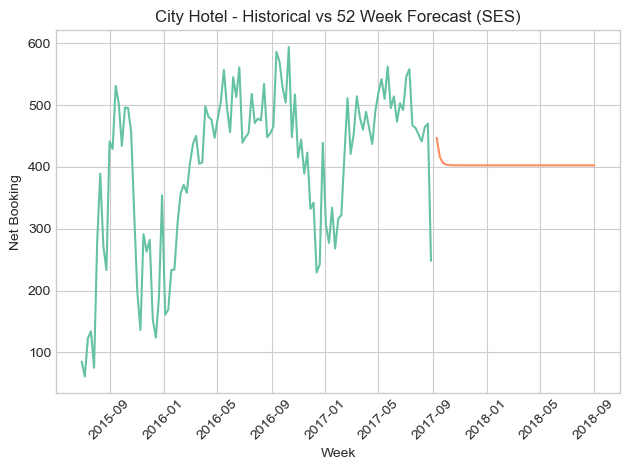

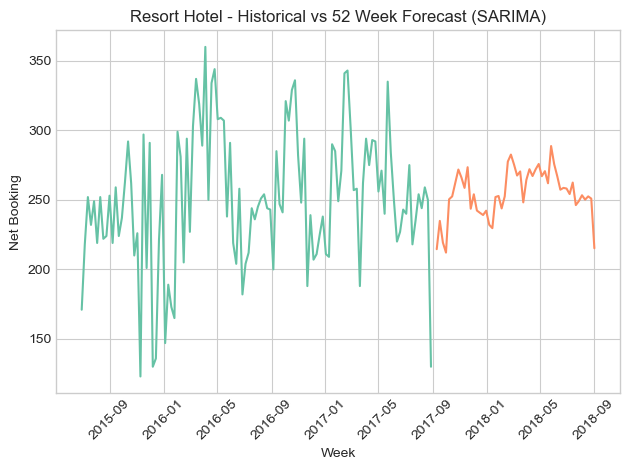

In [6]:
import matplotlib.pyplot as plt

# Separate forecasts
city_forecast = final_forecast_df[final_forecast_df['Hotel'] == 'City Hotel']
resort_forecast = final_forecast_df[final_forecast_df['Hotel'] == 'Resort Hotel']

city_actual = weekly[weekly['hotel'] == 'City Hotel'].sort_values('week_start')
resort_actual = weekly[weekly['hotel'] == 'Resort Hotel'].sort_values('week_start')

# -----------------------------
# Plot 1: City Hotel Forecast
# -----------------------------
plt.figure()

plt.plot(city_actual['week_start'], city_actual['net_booking'])
plt.plot(city_forecast['Week_Start'], city_forecast['Forecasted_Net_Booking'])

plt.title("City Hotel - Historical vs 52 Week Forecast (SES)")
plt.xlabel("Week")
plt.ylabel("Net Booking")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Resort Hotel Forecast
# -----------------------------
plt.figure()

plt.plot(resort_actual['week_start'], resort_actual['net_booking'])
plt.plot(resort_forecast['Week_Start'], resort_forecast['Forecasted_Net_Booking'])

plt.title("Resort Hotel - Historical vs 52 Week Forecast (SARIMA)")
plt.xlabel("Week")
plt.ylabel("Net Booking")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 6: Business Recommendations

In [7]:
# Generate capacity planning table for both hotels

capacity = []

for hotel in final_forecast_df['Hotel'].unique():

    hotel_forecasts = final_forecast_df[
        final_forecast_df['Hotel'] == hotel
    ]['Forecasted_Net_Booking']

    expected = hotel_forecasts.mean()
    min_capacity = expected * 0.85
    max_capacity = expected * 1.15

    capacity.append({
        'Hotel': hotel,
        'Expected Bookings/Week': int(round(expected)),
        'Minimum Capacity (85%)': int(round(min_capacity)),
        'Maximum Capacity (115%)': int(round(max_capacity)),
        'Recommended Buffer': '±15%'
    })

capacity_df = pd.DataFrame(capacity)
    
print("\n CAPACITY PLANNING RECOMMENDATIONS\n")
print(capacity_df.to_string(index=False))


 CAPACITY PLANNING RECOMMENDATIONS

       Hotel  Expected Bookings/Week  Minimum Capacity (85%)  Maximum Capacity (115%) Recommended Buffer
  City Hotel                     404                     343                      464               ±15%
Resort Hotel                     255                     217                      293               ±15%
